# RQ-VAE: семантические ID товаров

сжимаем контентный эмбеддинг каждого товара (384d) в 3 дискретных кода по 256 значений с помощью residual quantization: каждый следующий уровень квантует остаток предыдущего

## imports & install

In [ ]:
import os
import json
import numpy as np
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

## data

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

base_path = '/content/drive/MyDrive/pet_proj_recomendashki'
item_embeddings = np.load(f'{base_path}/data/item_embeddings.npy')
with open(f'{base_path}/data/items_to_idx.json') as f:
    items_to_idx = json.load(f)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(item_embeddings.shape, device)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
(26354, 384) cuda


## архитектура

In [ ]:
class VectorQuantizer(nn.Module):
    def __init__(self, latent_dim, num_codes, beta_loss):
        super().__init__()
        self.num_codes = num_codes
        self.latent_dim = latent_dim
        self.beta_loss = beta_loss
        self.codebook = nn.Embedding(num_codes, latent_dim)
        self.codebook.weight.data.normal_(0, 1.0)

    def forward(self, r):
        r_2 = (r ** 2).sum(dim=1, keepdim=True)
        codebook_2 = (self.codebook.weight ** 2).sum(dim=1)
        r_codebook = torch.matmul(r, self.codebook.weight.T)
        dist = r_2 + codebook_2.unsqueeze(0) - 2 * r_codebook
        idx = torch.argmin(dist, dim=1)
        quantized = self.codebook(idx)

        ## loss

        # чтобы codebook учился предсказывать выходное пространство encoder
        codebook_loss = F.mse_loss(quantized, r.detach())

        # чтобы удерживать выход encoder близко к существующим векторам
        commitment_loss = F.mse_loss(r, quantized.detach())

        vq_loss = codebook_loss + self.beta_loss * commitment_loss
        # чтобы градиент дошел до r
        quantized_st = r + (quantized - r).detach()

        return idx, quantized_st, vq_loss

In [ ]:
class ResidualQuantizer(nn.Module):
    def __init__(self, num_levels, latent_dim, num_codes, beta_loss):
        super().__init__()
        self.levels = nn.ModuleList([
            VectorQuantizer(latent_dim, num_codes, beta_loss) for i in range(num_levels)
        ])

    def forward(self, z):
        all_indices = []
        all_quantized = []
        total_vq_loss = 0

        for level in self.levels:
            idx, quantized_st, vq_loss = level(z)
            all_indices.append(idx)
            all_quantized.append(quantized_st)
            total_vq_loss += vq_loss
            z = z - quantized_st

        z_reconstructed = sum(all_quantized)
        all_indices = torch.stack(all_indices, dim=1)
        return all_indices, z_reconstructed, total_vq_loss

In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_dim, hidden_dim, latent_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, latent_dim),
            nn.LayerNorm(latent_dim)
        )

    def forward(self, z):
        return self.net(z)

class Decoder(nn.Module):
    def __init__(self, latent_dim, hidden_dim, output_dim):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(latent_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, z):
        return self.net(z)

In [ ]:
class RQ_VAE(nn.Module):
    def __init__(self, input_dim=384, hidden_dim=256, latent_dim=32, num_levels=3,
                 num_codes=256, beta_loss=0.25):
        output_dim = input_dim
        super().__init__()
        self.encoder = Encoder(input_dim, hidden_dim, latent_dim)
        self.decoder = Decoder(latent_dim, hidden_dim, output_dim)
        self.quantizer = ResidualQuantizer(num_levels, latent_dim, num_codes, beta_loss)

    def forward(self, x):
        #encoder -> quantizer -> decoder
        z = self.encoder(x)
        indices, z_reconstructed, vq_loss = self.quantizer(z)
        x_reconstructed = self.decoder(z_reconstructed)

        reconstruction_loss = F.mse_loss(x_reconstructed, x)
        total_loss = reconstruction_loss + vq_loss
        return {
            "indices": indices,
            "x_recon": x_reconstructed,
            "recon_loss": reconstruction_loss,
            "vq_loss": vq_loss,
            "total_loss": total_loss
            }

In [ ]:
class EmbeddingDataset(Dataset):
    def __init__(self, embeddings):
        self.embeddings = torch.from_numpy(embeddings).float()

    def __len__(self):
        return len(self.embeddings)

    def __getitem__(self, idx):
        return self.embeddings[idx]

## обучение

In [ ]:
dataset = EmbeddingDataset(item_embeddings)
dataloader = DataLoader(dataset, batch_size=256, shuffle=True)

In [ ]:
def train(model):
    max_epochs = 50
    model.train()
    hist = {'total_loss': [], 'reconstruction_loss': [], 'vq_loss': []}

    for epoch in range(max_epochs):
        epoch_total_loss = 0
        epoch_reconstruction_loss = 0
        epoch_vq_loss = 0
        n_batch = 0
        for batch in dataloader:
            n_batch += 1
            batch = batch.to(device)
            optimizer.zero_grad()

            output = model(batch)
            loss = output['total_loss']
            loss.backward()
            optimizer.step()

            epoch_total_loss += output['total_loss'].item()
            epoch_reconstruction_loss += output['recon_loss'].item()
            epoch_vq_loss += output['vq_loss'].item()

        avg_total_loss = epoch_total_loss / n_batch
        hist['total_loss'].append(avg_total_loss)
        avg_reconstruction_loss = epoch_reconstruction_loss / n_batch
        hist['reconstruction_loss'].append(avg_reconstruction_loss)
        avg_vq_loss = epoch_vq_loss / n_batch
        hist['vq_loss'].append(avg_vq_loss)

        print(f"""epoch {epoch + 1}
            total: {avg_total_loss}
            roconst: {avg_reconstruction_loss}
            vq: {avg_vq_loss}""")
    return hist

In [ ]:
model = RQ_VAE().to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=10 ** (-3))

In [ ]:
hist = train(model)

epoch 1
            total: 1.2826357148226024
            roconst: 0.006241445644369837
            vq: 1.2763942705774771
epoch 2
            total: 0.7908682927344609
            roconst: 0.0020836048343589584
            vq: 0.7887846885375607
epoch 3
            total: 0.5900813966121489
            roconst: 0.0020843439925353506
            vq: 0.5879970528547046
epoch 4
            total: 0.4576148118787599
            roconst: 0.0020848594705384334
            vq: 0.45552995222286113
epoch 5
            total: 0.3592004530059481
            roconst: 0.0020850825109925953
            vq: 0.35711536939861704
epoch 6
            total: 0.2822998760684023
            roconst: 0.0020851255326703624
            vq: 0.28021474978298816
epoch 7
            total: 0.22132360602466805
            roconst: 0.0020854833232944164
            vq: 0.2192381225453997
epoch 8
            total: 0.17293735846732428
            roconst: 0.002085849247167556
            vq: 0.17085150983727093
epoc

loss крайне мал, вроде отлично, но проверим, какие значения на каждом уровне используем модель

In [ ]:
model.eval()
all_indices = []

with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        all_indices.append(output['indices'].cpu())
all_indices = torch.cat(all_indices, dim=0)
for level in range(all_indices.shape[1]):
    unique_codes = torch.unique(all_indices[:, level])
    print(f"Уровень {level}: {len(unique_codes)} из {model.quantizer.levels[level].num_codes}")

Уровень 0: 1 из 256
Уровень 1: 1 из 256
Уровень 2: 1 из 256


модель тупо использует одну и ту же комбинацию для всех айтемов :D лосс низкий, но квантизация полностью схлопнулась

решаем через «оживление» неиспользуемых кодов: после каждой эпохи смотрим, сколько раз использовался каждый код, и если его не выбрал ни один товар — переинициализируем его случайным остатком из последнего батча (реальные данные, а не случайный шум, чтобы не вернуться к исходной проблеме)

In [ ]:
def train_with_dead_code_reset(model, dataloader, optimizer, device,
                                  max_epochs=50, reset_every=5, min_usage=1):
    hist = {'total_loss': [], 'reconstruction_loss': [], 'vq_loss': [], 'utilization': []}

    for epoch in range(max_epochs):
        model.train()
        epoch_total, epoch_recon, epoch_vq, n_batch = 0, 0, 0, 0

        usage_counters = [torch.zeros(level.num_codes) for level in model.quantizer.levels]
        last_residuals = [None] * len(model.quantizer.levels)

        for batch in dataloader:
            n_batch += 1
            batch = batch.to(device)
            optimizer.zero_grad()
            output = model(batch)
            loss = output['total_loss']
            loss.backward()
            optimizer.step()
            epoch_total += output['total_loss'].item()
            epoch_recon += output['recon_loss'].item()
            epoch_vq += output['vq_loss'].item()

            with torch.no_grad():
                z = model.encoder(batch)
                residual = z
                for i, level in enumerate(model.quantizer.levels):
                    idx, q_st, _ = level(residual)
                    usage_counters[i].scatter_add_(0, idx.cpu(), torch.ones_like(idx, dtype=torch.float, device='cpu'))
                    last_residuals[i] = residual.detach()
                    residual = residual - q_st

        avg_total = epoch_total / n_batch
        avg_recon = epoch_recon / n_batch
        avg_vq = epoch_vq / n_batch
        hist['total_loss'].append(avg_total)
        hist['reconstruction_loss'].append(avg_recon)
        hist['vq_loss'].append(avg_vq)

        if (epoch + 1) % reset_every == 0:
            total_reset = 0
            for i, level in enumerate(model.quantizer.levels):
                dead = (usage_counters[i] < min_usage).nonzero(as_tuple=True)[0]
                if len(dead) > 0 and last_residuals[i] is not None:
                    pool = last_residuals[i]
                    random_idx = torch.randint(0, pool.shape[0], (len(dead),))
                    level.codebook.weight.data[dead] = pool[random_idx].to(device)
                    total_reset += len(dead)
            print(f"reset {total_reset} мёртвых кодов на эпохе {epoch+1}")
        print(f"epoch {epoch+1} | total: {round(avg_total, 6)} | recon: {round(avg_recon, 6)} | vq: {round(avg_vq, 6)}")

    return hist

In [ ]:
model = RQ_VAE(input_dim=384, hidden_dim=256, latent_dim=32, num_levels=3, num_codes=256, beta_loss=0.1).to(device)
optimizer = torch.optim.Adam(model.parameters(), lr=10 ** (-3) * 4)

hist = train_with_dead_code_reset(model, dataloader, optimizer, device,
                                     max_epochs=50, reset_every=1, min_usage=1)

reset 709 мёртвых кодов на эпохе 1
epoch 1 | total: 0.962307 | recon: 0.00494 | vq: 0.957367
reset 389 мёртвых кодов на эпохе 2
epoch 2 | total: 0.067491 | recon: 0.002121 | vq: 0.06537
reset 342 мёртвых кодов на эпохе 3
epoch 3 | total: 0.002225 | recon: 0.001957 | vq: 0.000268
reset 298 мёртвых кодов на эпохе 4
epoch 4 | total: 0.002116 | recon: 0.001918 | vq: 0.000197
reset 280 мёртвых кодов на эпохе 5
epoch 5 | total: 0.002101 | recon: 0.001913 | vq: 0.000188
reset 295 мёртвых кодов на эпохе 6
epoch 6 | total: 0.002109 | recon: 0.001898 | vq: 0.000211
reset 289 мёртвых кодов на эпохе 7
epoch 7 | total: 0.002099 | recon: 0.001867 | vq: 0.000232
reset 266 мёртвых кодов на эпохе 8
epoch 8 | total: 0.002102 | recon: 0.00183 | vq: 0.000273
reset 251 мёртвых кодов на эпохе 9
epoch 9 | total: 0.002073 | recon: 0.001801 | vq: 0.000272
reset 223 мёртвых кодов на эпохе 10
epoch 10 | total: 0.002099 | recon: 0.001777 | vq: 0.000322
reset 215 мёртвых кодов на эпохе 11
epoch 11 | total: 0.00210

## результат

In [ ]:
model.eval()
all_indices = []
with torch.no_grad():
    for batch in dataloader:
        batch = batch.to(device)
        output = model(batch)
        all_indices.append(output['indices'].cpu())
all_indices = torch.cat(all_indices, dim=0)
unique_full_ids = torch.unique(all_indices, dim=0)
print(f"Уникальных полных ID: {len(unique_full_ids)} из {len(all_indices)} товаров")
print(f'процент коллизии: {round((1 - len(unique_full_ids) / len(all_indices)) * 100, 4)}%')
print()
for level in range(all_indices.shape[1]):
    unique_codes = torch.unique(all_indices[:, level])
    print(f"Уровень {level}: {len(unique_codes)} из {model.quantizer.levels[level].num_codes}")

Уникальных полных ID: 25275 из 26354 товаров
процент коллизии: 4.0943%

Уровень 0: 256 из 256
Уровень 1: 238 из 256
Уровень 2: 150 из 256


результат приемлемый: коллизии на уровне ~4%, первый уровень заполнен полностью

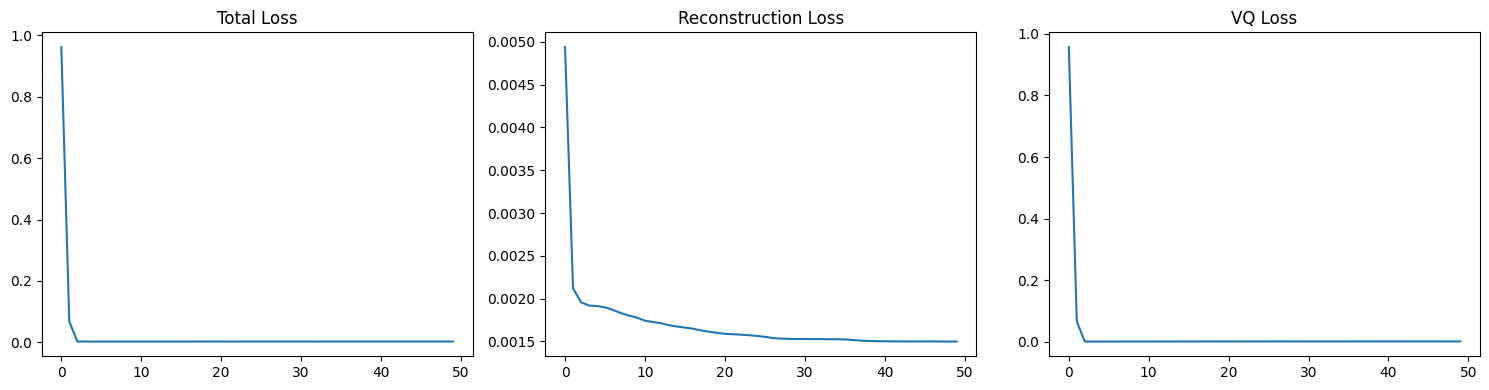

In [ ]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(hist['total_loss']); axes[0].set_title('Total Loss')
axes[1].plot(hist['reconstruction_loss']); axes[1].set_title('Reconstruction Loss')
axes[2].plot(hist['vq_loss']); axes[2].set_title('VQ Loss')
plt.tight_layout()
plt.show()

## save

In [ ]:
os.makedirs(f'{base_path}/checkpoints', exist_ok=True)
torch.save(model.state_dict(), f'{base_path}/checkpoints/rqvae_weights.pt')

## semantic IDs

ID собираем отдельным проходом по товарам строго по порядку (`shuffle=False`): строка `i` в `semantic_ids.npy` должна соответствовать товару с номером `i`

In [ ]:
model = RQ_VAE(input_dim=384, hidden_dim=256, latent_dim=32, num_levels=3, num_codes=256, beta_loss=0.1).to(device)
model.load_state_dict(torch.load(f'{base_path}/checkpoints/rqvae_weights.pt', map_location=device))
model.eval()

eval_loader = DataLoader(dataset, batch_size=256, shuffle=False)
semantic_ids = []
with torch.no_grad():
    for batch in eval_loader:
        semantic_ids.append(model(batch.to(device))['indices'].cpu())
semantic_ids = torch.cat(semantic_ids).numpy()

np.save(f'{base_path}/data/semantic_ids.npy', semantic_ids)
print(semantic_ids.shape, '| уникальных ID:', len(np.unique(semantic_ids, axis=0)))

(26354, 3) | уникальных ID: 25275


проверка, что ID действительно семантические: товары с одинаковым первым кодом должны быть ближе по описанию, чем случайные пары

In [ ]:
emb = item_embeddings / np.linalg.norm(item_embeddings, axis=1, keepdims=True)
rng = np.random.default_rng(0)
a = rng.integers(0, len(emb), 200000)
b = rng.integers(0, len(emb), 200000)
cos = (emb[a] * emb[b]).sum(1)
same = semantic_ids[a, 0] == semantic_ids[b, 0]
print('одинаковый 1-й код:', round(cos[same].mean(), 3), '| разный:', round(cos[~same].mean(), 3))

одинаковый 1-й код: 0.476 | разный: 0.2


RQ-VAE обучается без фиксированного seed, поэтому при повторном запуске коды получаются другими при том же качестве (здесь 4.09% коллизий и 0.476, в основном прогоне 3.99% и 0.479). трансформер в 03 обучен на ID из основного прогона, они сохранены в semantic_ids.npy